In [1]:
# conection to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# unziping dataset
!unzip /content/drive/MyDrive/data/Animals-10.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP

In [3]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
from PIL import Image
from collections import Counter

import torch
import torchvision
import torchvision.datasets
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
from torchvision.io import read_image

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# **loading data**

In [4]:
# counting number of images in classes
path = '/content/dataset/raw-img'
classes = os.listdir(path)

class_names = {}
for class_name in classes:
  class_names[class_name] = len(os.listdir(os.path.join(path, class_name)))

class_names

{'elefante': 1446,
 'cane': 4863,
 'scoiattolo': 1862,
 'cavallo': 2623,
 'farfalla': 2112,
 'gatto': 1668,
 'ragno': 4821,
 'pecora': 1820,
 'gallina': 3098,
 'mucca': 1866}

In [5]:
# sorting classes distribution for visualization
class_names_sorted = dict(reversed(sorted(class_names.items(), key=lambda item: item[1])))
class_names_sorted

{'cane': 4863,
 'ragno': 4821,
 'gallina': 3098,
 'cavallo': 2623,
 'farfalla': 2112,
 'mucca': 1866,
 'scoiattolo': 1862,
 'pecora': 1820,
 'gatto': 1668,
 'elefante': 1446}

In [6]:
# conversion to tensors
transform_test = transforms.Compose([
    transforms.Resize((64, 64)),                                   # setting one size for all images
    transforms.ToTensor(),                                           # converting to tensors
    transforms.Normalize((0.5,), (0.5,))
])

In [7]:
# conversion to tensors
transform = transforms.Compose([
    transforms.Resize((64, 64)),        # setting one size for all images
    transforms.RandomHorizontalFlip(),    # random horiz flip of images
    transforms.RandomRotation(15),        # random rotation
    transforms.ToTensor(),                # converting to tensors
    transforms.Normalize((0.5,), (0.5,))
])

In [8]:
# loading dataset
data = torchvision.datasets.ImageFolder(root='/content/dataset/raw-img', transform=None)

In [9]:
# getting classes names
classes = data.classes
print(f'data classes: {classes}, number of classes: {len(classes)}')

data classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo'], number of classes: 10


In [10]:
# transtating classes to english
translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow",
             "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel"}
classes_eng = [translate[animal] for animal in translate]

In [11]:
print(f'data classes: {classes_eng}, number of classes: {len(classes_eng)}')

data classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel'], number of classes: 10


In [12]:
data.classes

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [13]:
data.class_to_idx

{'cane': 0,
 'cavallo': 1,
 'elefante': 2,
 'farfalla': 3,
 'gallina': 4,
 'gatto': 5,
 'mucca': 6,
 'pecora': 7,
 'ragno': 8,
 'scoiattolo': 9}

In [14]:
counter = Counter(data.targets)
counter, data.class_to_idx

(Counter({0: 4863,
          1: 2623,
          2: 1446,
          3: 2112,
          4: 3098,
          5: 1668,
          6: 1866,
          7: 1820,
          8: 4821,
          9: 1862}),
 {'cane': 0,
  'cavallo': 1,
  'elefante': 2,
  'farfalla': 3,
  'gallina': 4,
  'gatto': 5,
  'mucca': 6,
  'pecora': 7,
  'ragno': 8,
  'scoiattolo': 9})

# **dividing dataset to train and test**

In [15]:
def count_classes(dataset):
    labels = [dataset.dataset.targets[i] for i in dataset.indices]
    class_counts = Counter(labels)
    for class_idx, count in class_counts.items():
        class_name = dataset.dataset.classes[class_idx]
        print(f"Class:\t{class_name} ({classes_eng[class_idx]}),\t\tInstances: {count}, \tPercent: {count / counter[class_idx] * 100}%")

In [16]:
# dividing dataset to train, validation and test
train_size = int(len(data) * 0.6)
test_size = int(len(data) * 0.2)
val_size = int(len(data) - train_size - test_size)

train_data, test_data, valid_data = random_split(dataset=data, lengths=[train_size, test_size, val_size])
print(f'train: {len(train_data)}, test: {len(test_data)}, validation: {len(valid_data)}')

train: 15707, test: 5235, validation: 5237


In [17]:
count_classes(train_data)

Class:	gatto (cat),		Instances: 1012, 	Percent: 60.671462829736214%
Class:	gallina (chicken),		Instances: 1866, 	Percent: 60.232408005164615%
Class:	cane (dog),		Instances: 2887, 	Percent: 59.36664610322846%
Class:	pecora (sheep),		Instances: 1118, 	Percent: 61.42857142857143%
Class:	cavallo (horse),		Instances: 1627, 	Percent: 62.02821197102555%
Class:	ragno (spider),		Instances: 2900, 	Percent: 60.15349512549264%
Class:	elefante (elephant),		Instances: 843, 	Percent: 58.298755186722%
Class:	farfalla (butterfly),		Instances: 1243, 	Percent: 58.854166666666664%
Class:	scoiattolo (squirrel),		Instances: 1104, 	Percent: 59.29108485499462%
Class:	mucca (cow),		Instances: 1107, 	Percent: 59.32475884244373%


In [18]:
count_classes(test_data)

Class:	mucca (cow),		Instances: 388, 	Percent: 20.79314040728832%
Class:	farfalla (butterfly),		Instances: 447, 	Percent: 21.164772727272727%
Class:	cane (dog),		Instances: 1019, 	Percent: 20.954143532798682%
Class:	gatto (cat),		Instances: 326, 	Percent: 19.544364508393286%
Class:	scoiattolo (squirrel),		Instances: 350, 	Percent: 18.796992481203006%
Class:	gallina (chicken),		Instances: 592, 	Percent: 19.109102646868948%
Class:	ragno (spider),		Instances: 955, 	Percent: 19.80916822236051%
Class:	pecora (sheep),		Instances: 373, 	Percent: 20.494505494505493%
Class:	elefante (elephant),		Instances: 300, 	Percent: 20.74688796680498%
Class:	cavallo (horse),		Instances: 485, 	Percent: 18.490278307281738%


In [19]:
count_classes(valid_data)

Class:	ragno (spider),		Instances: 966, 	Percent: 20.03733665214686%
Class:	cane (dog),		Instances: 957, 	Percent: 19.679210363972857%
Class:	cavallo (horse),		Instances: 511, 	Percent: 19.48150972169272%
Class:	gatto (cat),		Instances: 330, 	Percent: 19.784172661870503%
Class:	pecora (sheep),		Instances: 329, 	Percent: 18.076923076923077%
Class:	gallina (chicken),		Instances: 640, 	Percent: 20.65848934796643%
Class:	scoiattolo (squirrel),		Instances: 408, 	Percent: 21.911922663802365%
Class:	elefante (elephant),		Instances: 303, 	Percent: 20.95435684647303%
Class:	mucca (cow),		Instances: 371, 	Percent: 19.882100750267952%
Class:	farfalla (butterfly),		Instances: 422, 	Percent: 19.981060606060606%


## **adding transformation to datasets**

In [20]:
class SubsetWithTransform():
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

In [21]:
train_data = SubsetWithTransform(train_data, transform=transform)
test_data = SubsetWithTransform(test_data, transform=transform_test)
valid_data = SubsetWithTransform(valid_data, transform=transform)

In [22]:
train_data.transform, test_data.transform, valid_data.transform

(Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ToTensor()
     Normalize(mean=(0.5,), std=(0.5,))
 ),
 Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=(0.5,), std=(0.5,))
 ),
 Compose(
     Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ToTensor()
     Normalize(mean=(0.5,), std=(0.5,))
 ))

## **creating data loaders**

In [23]:
num_workers = 2

In [24]:
batch_size=64

In [25]:
# creating data loader
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
data_loader

In [26]:
# creating data loader for test and train data
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [27]:
# creating data loader for validation data
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# **start of part 2**

*Реалізація простої архітектури CNN*

## **task 1**

Визначте структуру моделі:
*  Заплануйте кількість згорткових шарів (наприклад, 2-3 згорткові
шари).
*  Для кожного згорткового шару визначте: *Кількість фільтрів. Розмір ядра згортки (**наприклад, 3x3 або 5x5**).*
*  Виріште, чи використовувати згортку з нулями (padding)
для збереження розміру зображення.
*  Визначте функції активації для згорткових шарів (наприклад,
ReLU).

In [28]:
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

    def forward(self, x):
        return x

**Підсумок**:

*   Модель має 2 згорткових шари.
*   Перший шар: *кількість фільтрів*: 32, *розмір ядра згортки*: 3x3.
*   Другий шар: *кількість фільтрів*: 64, *розмір ядра згортки*: 3x3.
*   Згортка з нулями використовується, її значення - 1.

## **task 2**

Додайте Pooling:
*   Включіть шари max pooling після згорткових шарів, щоб зменшити
розмір простору ознак.

In [29]:
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        return x

## **task 3**

Додайте повнозв’язані (Dense) шари:
* Введіть один або два повнозв'язані шари перед вихідним шаром.
* Зазначте, скільки нейронів буде в кожному шарі (наприклад, 128
або 256).
* Виберіть функцію активації для останнього повнозв'язаного
шару (наприклад, Softmax для багатокласової класифікації).

In [30]:
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(in_features=64 * 16 * 16, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        return x

## **task 4**

Створіть модель:
* Використовуйте бібліотеки (наприклад, Keras чи PyTorch) для
реалізації архітектури.

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, padding=1, filter_size=3, pool_size=2):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=filter_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=pool_size, stride=pool_size)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=filter_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=pool_size, stride=pool_size)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=filter_size, padding=padding)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=pool_size, stride=pool_size)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=filter_size, padding=padding)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=pool_size, stride=pool_size)

        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [32]:
model = CNNModel()
model

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [33]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
model.to(device)

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

# **2.** *Налаштування функції втрат і оптимізатора*

Визначте функцію втрат:
* Для задачі класифікації виберіть функцію втрат, наприклад,
categorical crossentropy (для багатокласового завдання).

In [34]:
loss_function = nn.CrossEntropyLoss()

Вибір оптимізатора:
* Виберіть оптимізатор, наприклад, Adam або SGD.
* Якщо використовуєте Adam, можете налаштувати такі параметри,
як learning rate (наприклад, 0.001).
* Визначте, чи потрібно застосовувати зменшення learning rate під
час навчання (learning rate scheduling).

In [35]:
optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler_adam = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=10, gamma=0.1)

**Підсумки**:
* Я вирішила використовувати оптимізатор Adam та додала зміну learning rate кожні 10 епох.

# **3.** *Тренування моделі на невеликій кількості епох*

Налаштуйте параметри тренування:
* Визначте кількість епох (напр., 20-30) та розмір батча (наприклад,
32 або 64).
* Незабудьте про використання валідаційного набору для оцінки та
корекції навчання.

In [36]:
batch_size

64

In [37]:
number_epochs = 40
number_epochs

40

In [38]:
len(valid_data), valid_loader.batch_size

(5237, 64)

Тренування моделі:
* Запустіть тренування на підготовленому наборі даних,
перевіряючи метрики, які ви визначили (точність, F1-score та ін.).
* Після завершення тренування збережіть навчений модель для
подальшого використання.

**тренування моделі з оптимайзером adam**

In [39]:
len(train_data)

15707

In [40]:
optimizer = optimizer_adam
scheduler = scheduler_adam

In [41]:
print(f'Model: {model},\n\nLoss function: {loss_function},\n\nOptimizer: {optimizer},\n\nScheduler: {scheduler}')

Model: CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, 

In [42]:
def evaluate_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return accuracy * 100, precision, recall, f1

In [43]:
train_loss_list = []
val_loss_list = []
train_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}
val_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}

for epoch in range(number_epochs):
    model.train()
    train_loss = torch.tensor(0.0, device=device)

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss = train_loss.item() / len(train_loader)
    train_loss_list.append(train_loss)

    train_accuracy, train_precision, train_recall, train_f1 = evaluate_metrics(model, train_loader)
    train_metrics['accuracy'].append(train_accuracy)
    train_metrics['f1_score'].append(train_f1)
    train_metrics['recall_score'].append(train_recall)
    train_metrics['precision'].append(train_precision)

    model.eval()
    val_loss = torch.tensor(0.0, device=device)

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            val_loss += loss.item()

    val_loss = val_loss.item() / len(valid_loader)
    val_loss_list.append(val_loss)

    val_accuracy, val_precision, val_recall, val_f1 = evaluate_metrics(model, valid_loader)
    val_metrics['accuracy'].append(val_accuracy)
    val_metrics['f1_score'].append(val_f1)
    val_metrics['recall_score'].append(val_recall)
    val_metrics['precision'].append(val_precision)

    print(f"Epoch {epoch+1}/{number_epochs}:"
          f"\n\tTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,"
          f"\n\tTrain Precision: {train_precision:.4f}, Train Recall: {train_recall:.4f}, Train F1-score: {train_f1:.4f}"
          f"\n\tVal Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%,"
          f"\n\tVal Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1-score: {val_f1:.4f}\n")

Epoch 1/40:
	Train Loss: 1.7679, Train Accuracy: 47.53%,
	Train Precision: 0.5396, Train Recall: 0.4000, Train F1-score: 0.3890
	Val Loss: 1.5476, Validation Accuracy: 46.46%,
	Val Precision: 0.4643, Val Recall: 0.3895, Val F1-score: 0.3791

Epoch 2/40:
	Train Loss: 1.3537, Train Accuracy: 51.72%,
	Train Precision: 0.5143, Train Recall: 0.4540, Train F1-score: 0.4257
	Val Loss: 1.4084, Validation Accuracy: 50.77%,
	Val Precision: 0.4627, Val Recall: 0.4451, Val F1-score: 0.4128

Epoch 3/40:
	Train Loss: 1.1844, Train Accuracy: 60.63%,
	Train Precision: 0.6030, Train Recall: 0.5378, Train F1-score: 0.5356
	Val Loss: 1.1815, Validation Accuracy: 60.00%,
	Val Precision: 0.5935, Val Recall: 0.5311, Val F1-score: 0.5256

Epoch 4/40:
	Train Loss: 1.0789, Train Accuracy: 64.69%,
	Train Precision: 0.6596, Train Recall: 0.5955, Train F1-score: 0.6063
	Val Loss: 1.1177, Validation Accuracy: 62.29%,
	Val Precision: 0.6327, Val Recall: 0.5729, Val F1-score: 0.5844

Epoch 5/40:
	Train Loss: 0.9977,

Text(0.5, 1.0, 'Train Recall Score')

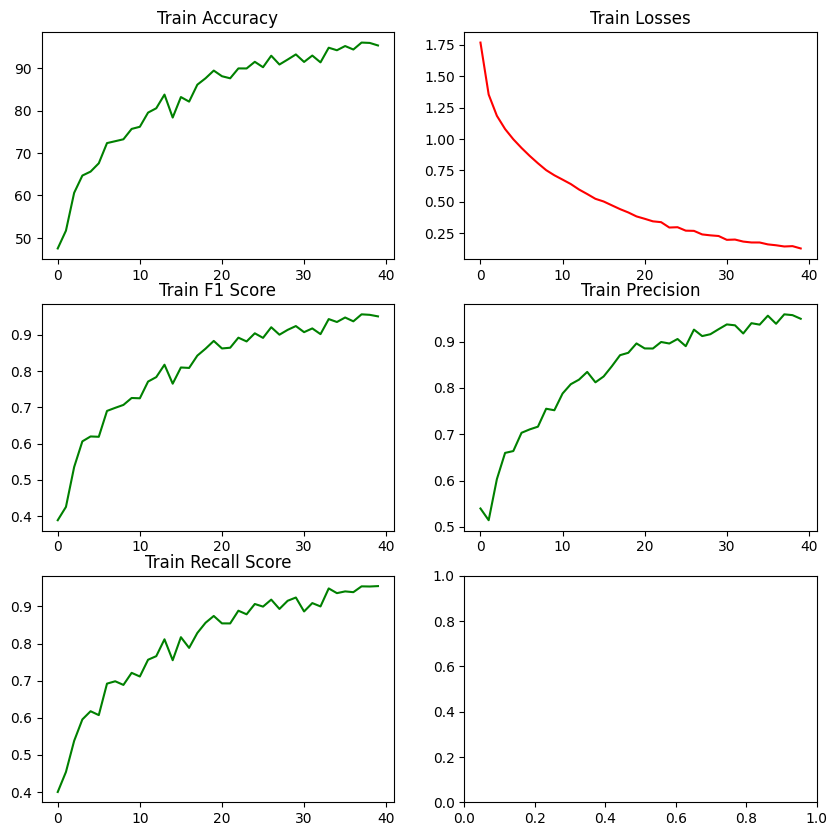

In [44]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(train_metrics['accuracy'], color='g')
ax[0,0].set_title('Train Accuracy')

ax[0,1].plot(train_loss_list, color='r')
ax[0,1].set_title('Train Losses')

ax[1,0].plot(train_metrics['f1_score'], color='g')
ax[1,0].set_title('Train F1 Score')

ax[1,1].plot(train_metrics['precision'], color='g')
ax[1,1].set_title('Train Precision')

ax[2,0].plot(train_metrics['recall_score'], color='g')
ax[2,0].set_title('Train Recall Score')

Text(0.5, 1.0, 'Validation Recall Score')

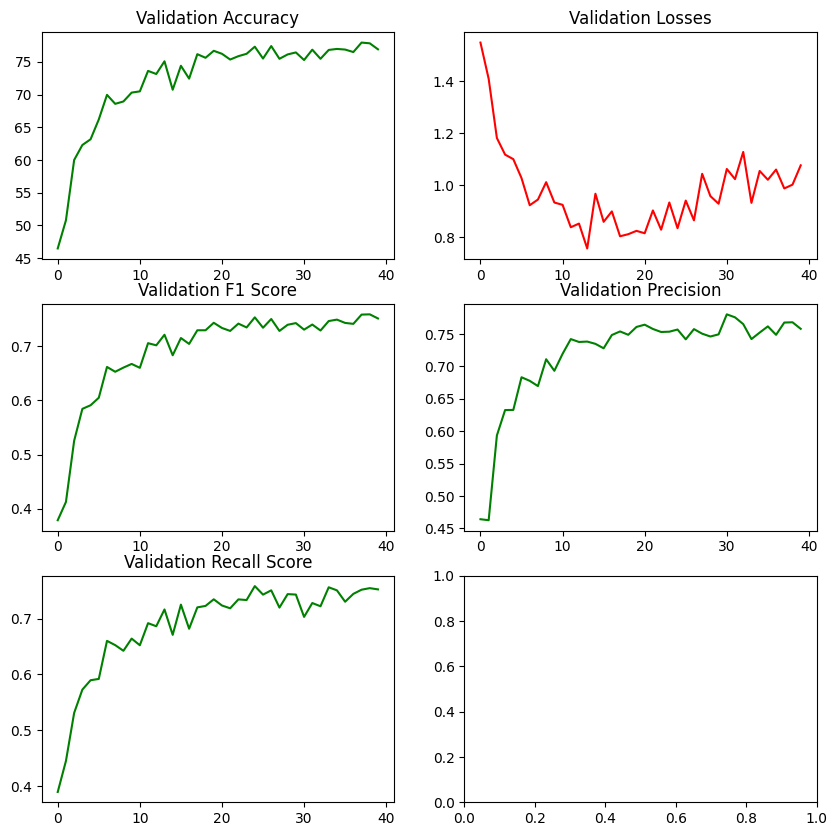

In [45]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(val_metrics['accuracy'], color='g')
ax[0,0].set_title('Validation Accuracy')

ax[0,1].plot(val_loss_list, color='r')
ax[0,1].set_title('Validation Losses')

ax[1,0].plot(val_metrics['f1_score'], color='g')
ax[1,0].set_title('Validation F1 Score')

ax[1,1].plot(val_metrics['precision'], color='g')
ax[1,1].set_title('Validation Precision')

ax[2,0].plot(val_metrics['recall_score'], color='g')
ax[2,0].set_title('Validation Recall Score')

In [46]:
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

In [47]:
print(all_labels)
print(all_preds)

[np.int64(6), np.int64(3), np.int64(0), np.int64(0), np.int64(5), np.int64(9), np.int64(4), np.int64(5), np.int64(8), np.int64(3), np.int64(4), np.int64(0), np.int64(8), np.int64(6), np.int64(7), np.int64(7), np.int64(3), np.int64(8), np.int64(0), np.int64(4), np.int64(0), np.int64(2), np.int64(6), np.int64(6), np.int64(2), np.int64(5), np.int64(1), np.int64(6), np.int64(8), np.int64(8), np.int64(5), np.int64(0), np.int64(8), np.int64(4), np.int64(1), np.int64(1), np.int64(8), np.int64(0), np.int64(5), np.int64(9), np.int64(1), np.int64(9), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(7), np.int64(5), np.int64(1), np.int64(8), np.int64(0), np.int64(9), np.int64(8), np.int64(2), np.int64(4), np.int64(0), np.int64(8), np.int64(9), np.int64(8), np.int64(4), np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(7), np.int64(8), np.int64(8), np.int64(2), np.int64(0), np.int64(2), np.int64(3), np.int64(9), np.int64(5), np.int64(8), np.int64(0), np.int64(5), np.int64(4)

In [48]:
len(all_labels)

5235

In [49]:
count_similar = 0
for i in range(len(all_labels)):
  if all_labels[i] == all_preds[i]:
    count_similar += 1

count_similar

3991

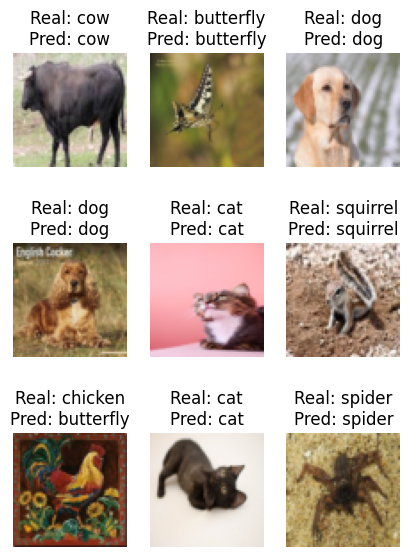

In [50]:
fig, axes = plt.subplots(3, 3, figsize=(5, 7))
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = outputs.max(1)

for i, ax in enumerate(axes.flat):
    img = images[i]
    img = img / 2 + 0.5
    img = img.cpu().numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(f'Real: {classes_eng[labels[i].item()]}\nPred: {classes_eng[predicted[i].item()]}')
    ax.axis('off')
plt.show()

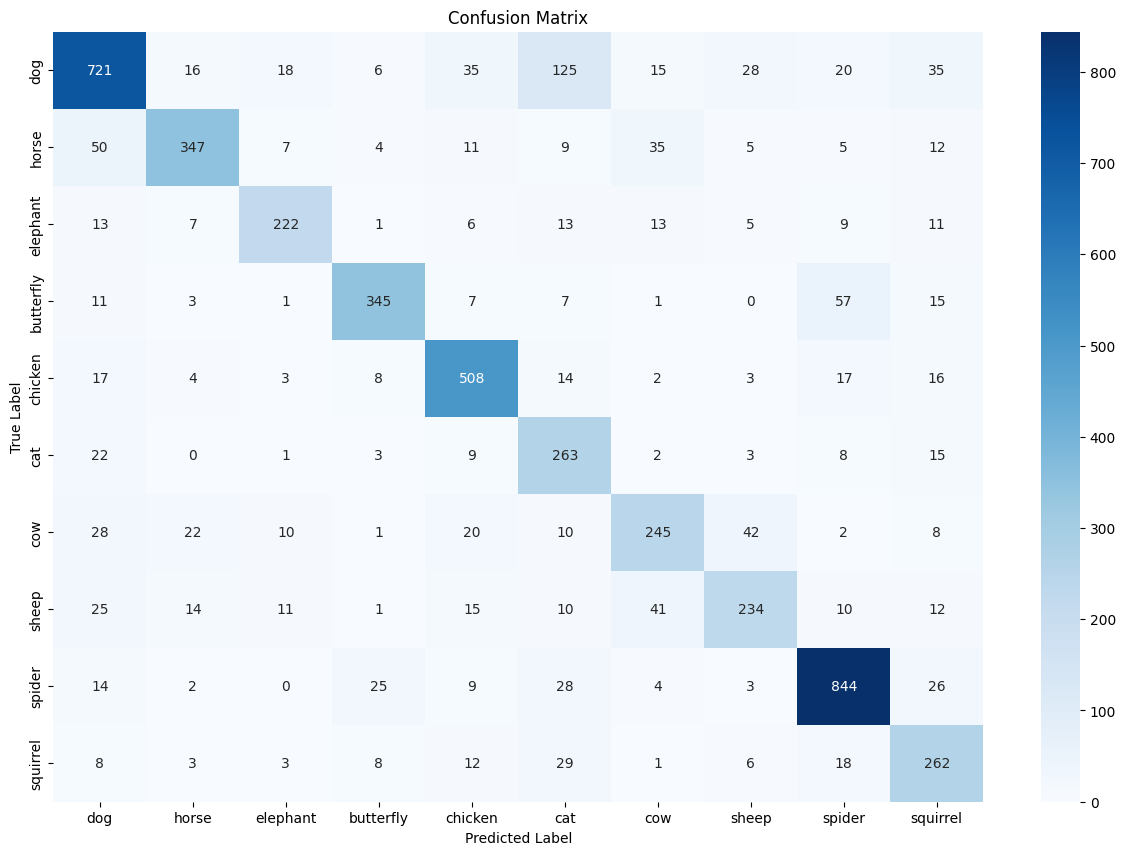

In [51]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_eng, yticklabels=classes_eng)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [52]:
torch.save(model.state_dict(), 'animal10_cnn.pth')